# Workshop 1 with large data set

In this workshop, we will use real data imported from csv file (boston.csv) instead of made-up ones

We will:

1. load real data
2. visualize relationships
3. train a linear regression model
4. make predictions
5. evaluate accuracy
6. visualize the regression line

## STEP 1 - IMPORT REQUIRED LIBRARIES


In [1]:
# import everything we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

In [ ]:
''' 
Variables in order:
 CRIM     per capita crime rate by town
 ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
 INDUS    proportion of non-retail business acres per town
 CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
 NOX      nitric oxides concentration (parts per 10 million)
 RM       average number of rooms per dwelling
 AGE      proportion of owner-occupied units built prior to 1940
 DIS      weighted distances to five Boston employment centres
 RAD      index of accessibility to radial highways
 TAX      full-value property-tax rate per $10,000
 PTRATIO  pupil-teacher ratio by town
 B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
 LSTAT    % lower status of the population
 MEDV     Median value of owner-occupied homes in $1000's
 '''

## STEP 2 - LOAD DATASET
Construct a dataframe for our data and target for a better illustration and show first 5 rows

In [14]:
# Construct a dataframe for our data and target for a better illustration
# set the columns names according to the result above

# Define column headers
# headers = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# Load csv file
boston_df = pd.read_csv('boston.csv', index_col = 0)

# Show first 5 rows
print(boston_df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


## STEP 3 - DATA VISUALISATION
We can see that feature 'RM', average number of rooms per dwelling, has a linear relationship with our target 'MEDV', Median value of owner-occupied homes in $1000's.

Check whether this relationship is truly linear. 

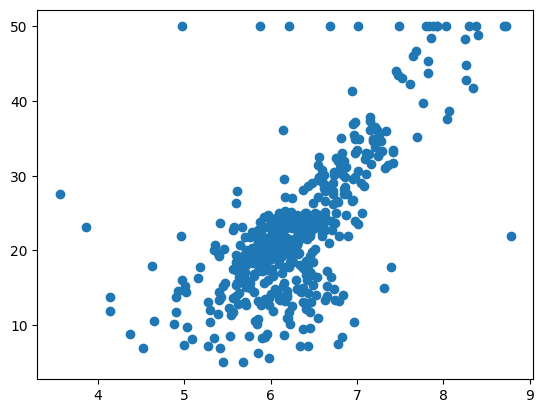

In [18]:
# 1. Create the scatter plot
# Allow plots to appear within notebook
%matplotlib inline

# Plot and show
plt.scatter(boston_df.RM, boston_df.MEDV)

# 2. Display the scatter plot
plt.show()

# 3. From observation of the scatter plot, explain why linear regression is suitable
# Most of the data are in a line, with few outliers outside of the linear trajectory

## STEP 4 - MODEL TRAINING

1. Imports
2. 'RM' as predictor, 'MEDV' as target; split data set into training & testing sets
3. Instantiate linear regression model and train (fit) it with training & testing sets

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [25]:
# Identify predictor (input; x) vs target (output; y)
pred = boston_df[['RM']]
targ = boston_df[['MEDV']]

# define train/test sets
x_train, x_test, y_train, y_test = train_test_split(pred, targ, test_size = 0.2, random_state = 42)

print(x_train.shape)
print(y_train.shape)

# Instantiate linear reg model
lin = LinearRegression()

# Fit model to train set data
lin.fit(x_train, y_train)

(404, 1)
(404, 1)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## STEP 5 - PREDICTION
Now that we've trained our model, the next step is to predict the data.

1. Generate predictions using LinearRegression.predict()

In [29]:
# Predict MEDV when RM is > 5 and > 6
prediction = lin.predict(pd.DataFrame({'RM': [5, 6]}))
print(prediction)

[[10.49518813]
 [19.84348954]]


## STEP 6 - MODEL VALIDATION

We want to see how well our model fits the data. r2-score should be as close to 1 as possible

1. Validate against actual values
2. Display coefficient & intercept

In [33]:
from sklearn.metrics import r2_score

# Validate against actual
y_predict = lin.predict(x_test)
print('R2 score:', r2_score(y_test, y_predict))

# Display coefficient & intercept
print(lin.intercept_)
print(lin.coef_)

R2 score: 0.3707569232254778
[-36.2463189]
[[9.34830141]]


As the r2-score isn't very close to 1, our linear regression model doesn't really fit the data well
We can visualize it to see what the model looks like

Plot the regression line (blue) vs the actual value (red)

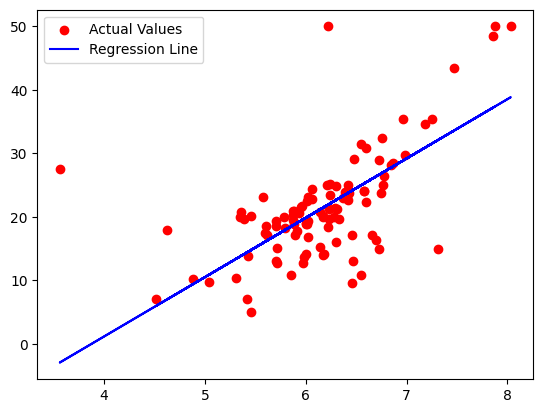

In [37]:
# We want to plot the regression line(blue) vs the actual value(red)

plt.scatter(x_test, y_test, color = 'red', label = 'Actual Values')
plt.plot(x_test, y_predict, color = 'blue', label = 'Regression Line')

plt.legend()
plt.show()